In [67]:
using Parameters, QuantEcon, NLopt
using Random, LinearAlgebra, Interpolations, Base.Threads, DataFrames, Statistics
using Plots, Statistics, ProgressMeter, ForwardDiff, Distributions, Profile
using DataFrames, Measures, StatsBase, LaTeXStrings, Printf, FastGaussQuadrature

In [68]:
# -------------------------------
# Utility: Nonlinear Grid Creator
# -------------------------------
function nonlinspace(start::Float64, stop::Float64, num::Int, curv::Float64)
    lin_vals = range(0, stop=1, length=num)
    curved_vals = lin_vals .^ curv
    return start .+ (stop - start) .* curved_vals
end

function create_focused_grid(a_min::Float64, a_focus::Float64, a_max::Float64, Na::Int, focus_share::Float64, curv::Float64)
    Na_focus = ceil(Int, Na * focus_share)
    Na_rest = Na - Na_focus
    grid_focus = nonlinspace(a_min, a_focus, Na_focus, curv)
    grid_rest = nonlinspace(a_focus, a_max, Na_rest + 1, curv)[2:end]
    return vcat(grid_focus, grid_rest)
end

# =============================================================================
# Dynamic Labor Model with College Decision and AR1 Shock
# =============================================================================
mutable struct ConSavLaborCollege_AR1
    T::Int; t_college::Int; rho::Float64; beta::Float64; phi::Float64
    eta::Float64; alpha::Float64; y::Float64; w::Float64; tau::Float64
    r::Float64; a_max::Float64; a_min::Float64; Na::Int; k_max::Float64
    Nk::Int; simT::Int; simN::Int
    a_grid::Vector{Float64}; k_grid::Vector{Float64}

    psi_terminal::Float64       # Terminal value weight on human capital
    kappa_terminal::Float64     # Weight on parent's retained assets
    omega::Float64              # Weight on child's life-cycle utility
    mu::Float64                 # Weight on Parent's utility

    # Transitory shocks
    Nt::Int                     # Number of grid points for t
    t_grid::Vector{Float64}     # Grid for transitory shock t
    sigma_eps::Float64          # Std dev of transitory shock
    t_weight::Vector{Float64}   # Weights for t quadrature

    # --- Stochastic Shock Parameters (AR1 only) ---
    Np::Int; p_grid::Vector{Float64}; p_transition::Matrix{Float64}
    p_ar1::Float64; sigma_p::Float64

    # --- Solution arrays (5D: T, Na, Nk, Np, Nt) ---
    sol_c_work::Array{Float64, 5}; sol_h_work::Array{Float64, 5}; sol_v_work::Array{Float64, 5}
    sol_c_college::Array{Float64, 5}; sol_h_college::Array{Float64, 5}; sol_v_college::Array{Float64, 5}

    # --- Solution arrays (4D: Na, Nk, Np, Nt) ---
    sol_tr_college::Array{Float64, 4}; sol_tr_work::Array{Float64, 4}
    sol_tr_v_college::Array{Float64, 4}; sol_tr_v_work::Array{Float64, 4}
    sol_exp_college::Array{Float64, 4}; sol_exp_v_college::Array{Float64, 4}

    # --- Simulation arrays ---
    sim_c::Matrix{Float64}; sim_h::Matrix{Float64}; sim_a::Matrix{Float64}
    sim_k::Matrix{Float64}; sim_p_idx::Matrix{Int}
    sim_a_init::Vector{Float64}; sim_k_init::Vector{Float64}; sim_p_init_idx::Vector{Int}
    sim_income::Matrix{Float64}; sim_wage::Matrix{Float64}
    draws_uniform_p::Matrix{Float64}
    w_vec::Vector{Float64}; college_cost::Float64; college_boost::Float64
    kappa::Float64 # parameter for psychic cost
    t_retire::Int                # Retirement time
    h_avg::Float64               # Average labor effort (initialized to 0)
    tax_lambda::Float64          # Progressive tax parameter (not used in AR1 model)
end

# =============================================================================
# Constructor for ConSavLaborCollege_AR1 with AR1 Shock
# =============================================================================
function ConSavLaborCollege_AR1(;
                T::Int=52, t_college::Int=4, beta::Float64=0.97, rho::Float64=1.0,
                r::Float64=0.03, a_max::Float64=100.0, Na::Int=30, y::Float64=0.6,
                simN::Int=5000, a_min::Float64=0.01, k_max::Float64=30.0, Nk::Int=30,
                w::Float64=12.5, tau::Float64=0.18, eta::Float64=2.0, alpha::Float64=0.08,
                phi::Float64=18.0, seed::Int=1234, college_cost::Float64=1.2,
                college_boost::Float64=2.0, kappa::Float64=5.0,
                # Shock parameters (AR1 only)
                p_ar1::Float64=0.95, sigma_p::Float64=0.2, Np::Int=5,
                # Preference shock parameters
                Nt=11, sigma_eps=0.5,
                # --- Terminal value parameters ---
                psi_terminal::Float64=1.0, kappa_terminal::Float64=10.0, omega::Float64=0.5,
                    # --- Bargaining parameter ---
                mu = 0.5,
                t_retire::Int=42,
                h_avg::Float64=0.4,
                tax_lambda::Float64=0.82
                )

    simT = T
    a_grid = create_focused_grid(a_min, 10.0, a_max, Na, 0.25, 1.0)
    k_grid = nonlinspace(0.001, k_max, Nk, 1.5)

    # Gauss-Hermite quadrature for transitory shocks
    nodes, weights = gausshermite(Nt)
    t_grid = sqrt(2) * sigma_eps .* nodes
    t_weight = weights / sqrt(pi)

    # --- Setup Persistent AR1 Shock ---
    mc = tauchen(Np, p_ar1, sigma_p, 0.0, 3)
    p_grid = exp.(mc.state_values)
    p_transition = mc.p

    # --- Initialize solution arrays (5D) ---
    sol_shape = (T, Na, Nk, Np, Nt)
    sol_c_work = fill(NaN, sol_shape); sol_h_work = fill(NaN, sol_shape); sol_v_work = fill(NaN, sol_shape)
    sol_c_college = fill(NaN, sol_shape); sol_h_college = fill(NaN, sol_shape); sol_v_college = fill(NaN, sol_shape)

    # --- Initialize half period solution arrays (5D) ---
    tr_shape = (Na, Nk, Np, Nt)
    sol_tr_college = fill(NaN, tr_shape); sol_tr_work = fill(NaN, tr_shape)
    sol_tr_v_college = fill(NaN, tr_shape); sol_tr_v_work = fill(NaN, tr_shape)
    sol_exp_college = fill(NaN, tr_shape); sol_exp_v_college = fill(NaN, tr_shape)

    # --- Initialize simulation arrays ---
    sim_shape = (simN, T)
    sim_c = fill(NaN, sim_shape); sim_h = fill(NaN, sim_shape)
    sim_a = fill(NaN, (simN, T+1)); sim_k = fill(NaN, sim_shape)
    sim_p_idx = fill(0, sim_shape)
    sim_income = fill(NaN, sim_shape); sim_wage = fill(NaN, sim_shape)

    rng = MersenneTwister(seed)
    sim_a_init = rand(rng, simN) .* 20
    sim_k_init = rand(rng, simN) .* 5
    sim_p_init_idx = fill(ceil(Int, Np/2), simN) # Start at median persistent shock

    draws_uniform_p = rand(rng, sim_shape...)
    w_vec = fill(w, T)

    return ConSavLaborCollege_AR1(
        T, t_college, rho, beta, phi, eta, alpha, y, w, tau, r,
        a_max, a_min, Na, k_max, Nk, simT, simN, a_grid, k_grid,
        psi_terminal, kappa_terminal, omega, mu,
        Nt, t_grid, sigma_eps, t_weight,
        Np, p_grid, p_transition, p_ar1, sigma_p,
        sol_c_work, sol_h_work, sol_v_work, sol_c_college, sol_h_college, sol_v_college,
        sol_tr_college, sol_tr_work, sol_tr_v_college, sol_tr_v_work,
        sol_exp_college, sol_exp_v_college,
        sim_c, sim_h, sim_a, sim_k, sim_p_idx,
        sim_a_init, sim_k_init, sim_p_init_idx, sim_income, sim_wage,
        draws_uniform_p, w_vec, college_cost, college_boost, kappa, t_retire, h_avg, tax_lambda
    )
end




ConSavLaborCollege_AR1

In [69]:
const WAGE_SCALING_FACTOR = 0.584

# ================================
# Progressive tax helpers
# ================================
# Pre-tax hourly wage (no taxes here)
@inline function wage_func(model::ConSavLaborCollege_AR1, k::Float64, t::Int, p_shock::Float64)
    base_wage = model.w_vec[t] * (1 + model.alpha * k)
    return base_wage * p_shock * WAGE_SCALING_FACTOR
end

# After-tax labor income: λ * (w*h)^(1 - τ)
@inline function after_tax_income(model::ConSavLaborCollege_AR1, w_pre::Float64, h::Float64)
    return model.tax_lambda * (w_pre * h)^(1.0 - model.tau)
end

# d/dh of after-tax labor income
# = λ (1-τ) * w * (w*h)^(-τ)
@inline function d_after_tax_dh(model::ConSavLaborCollege_AR1, w_pre::Float64, h::Float64)
    return model.tax_lambda * (1.0 - model.tau) * w_pre * (w_pre * h)^(-model.tau)
end

# ================================
# Work-path solver (with progressive tax and shock-free retirement)
# ================================
function solve_model_work!(model::ConSavLaborCollege_AR1)
    @unpack T, Na, Nk, Np, a_grid, k_grid, p_grid = model
    @unpack sol_c_work, sol_h_work, sol_v_work = model
    @unpack h_avg, t_retire, y = model

    # ---- Final period (t = T): retirement, consume all, no bequest ----
    for i_a in 1:Na, i_k in 1:Nk
        assets  = a_grid[i_a]
        capital = k_grid[i_k]
        w_pre   = wage_func(model, capital, T, 1.0)                 # no shock in retirement
        # Progressive-tax pension based on notional earnings (0.5 replacement factor)
        pension = 0.5 * after_tax_income(model, w_pre, h_avg)
        cons    = assets + pension + y
        sol_h_work[T, i_a, i_k, :, :] .= 0.0
        sol_c_work[T, i_a, i_k, :, :] .= cons
        sol_v_work[T, i_a, i_k, :, :] .= util_retire(model, cons)   # no continuation value
    end

    # ---- Retirement periods (t = T-1 down to t_retire) ----
    for t in (T-1):-1:t_retire
        interp = create_interpolator_retire(model, sol_v_work, t + 1)
        for i_a in 1:Na, i_k in 1:Nk
            assets  = a_grid[i_a]
            capital = k_grid[i_k]
            w_pre   = wage_func(model, capital, t, 1.0)
            pension = 0.5 * after_tax_income(model, w_pre, h_avg)   # progressive-tax pension

            # Objective with gradient (SLSQP): maximize V => minimize -V
            function obj_retire(c_vec::Vector{Float64}, grad::Vector{Float64})
                V = value_of_retirement(model, c_vec[1], assets, capital, t, interp, pension, grad)
                if length(grad) > 0
                    grad[1] = -grad[1]     # negate for minimization
                end
                return -V
            end

            opt = Opt(:LD_SLSQP, 1)
            lower_bounds!(opt, 1e-3)
            upper_bounds!(opt, [assets + pension + y])                 # trivial cap; constraint binds anyway
            ftol_rel!(opt, 1e-8)
            maxeval!(opt, 1000)
            inequality_constraint!(opt, (x,grad) -> asset_constraint_retire(x, grad, model, assets, pension), 1e-6)
            min_objective!(opt, obj_retire)

            init = [clamp(sol_c_work[t + 1, i_a, i_k, 1, 1], 1e-3, assets + pension + y)]
            (minf, c_opt, ret) = optimize(opt, init)

            sol_c_work[t, i_a, i_k, :, :] .= c_opt[1]
            sol_h_work[t, i_a, i_k, :, :] .= 0.0
            sol_v_work[t, i_a, i_k, :, :] .= -minf
        end
    end

    # ---- Working ages (t = t_retire-1 down to 1) ----
    @showprogress 1 "Solving working model..." for t in (t_retire-1):-1:1
        interp = create_interpolator(model, sol_v_work, t + 1)
        for i_p in 1:Np, i_k in 1:Nk, i_a in 1:Na
            assets, capital = a_grid[i_a], k_grid[i_k]
            p_shock = p_grid[i_p]

            function obj_wrapper(x::Vector, grad::Vector)
                f = obj_work_period(model, x, assets, capital, t, p_shock, i_p, interp, grad)
                if length(grad) > 0
                    grad[:] = -grad[:]  # negate for minimization
                end
                return -f
            end

            opt = Opt(:LD_SLSQP, 2)
            lower_bounds!(opt, [0.01, 1e-3])
            upper_bounds!(opt, [50.0, 1.0])
            ftol_rel!(opt, 1e-8)
            maxeval!(opt, 1000)
            inequality_constraint!(opt, (x, grad) -> asset_constraint_work(x, grad, model, assets, capital, t, p_shock), 1e-6)
            min_objective!(opt, obj_wrapper)

            init = [max(sol_c_work[t + 1, i_a, i_k, i_p, 1], 1e-6), 0.4]
            (minf, x_opt, ret) = optimize(opt, init)
            sol_c_work[t, i_a, i_k, i_p, :] .= x_opt[1]
            sol_h_work[t, i_a, i_k, i_p, :] .= x_opt[2]
            sol_v_work[t, i_a, i_k, i_p, :] .= -minf
        end
    end
end

# ================================
# College-path solver (unchanged)
# ================================
function solve_model_college!(model::ConSavLaborCollege_AR1)
    @unpack T, t_college, Na, Nk, Np, a_grid, k_grid, p_grid = model
    @unpack sol_c_college, sol_h_college, sol_v_college, sol_v_work = model

    # Pre-calc min required assets per college year
    a_min_t = compute_min_assets(model)

    @showprogress 1 "Solving college model..." for t in T:-1:1
        if t > t_college
            sol_c_college[t, :, :, :, :] .= model.sol_c_work[t, :, :, :, :]
            sol_h_college[t, :, :, :, :] .= model.sol_h_work[t, :, :, :, :]
            sol_v_college[t, :, :, :, :] .= model.sol_v_work[t, :, :, :, :]

        else
            interp = create_interpolator(model, model.sol_v_college, t + 1)
            for i_p in 1:model.Np, i_k in 1:model.Nk, i_a in 1:model.Na
                assets, capital = model.a_grid[i_a], model.k_grid[i_k]
                if assets < a_min_t[t]
                    model.sol_c_college[t, i_a, i_k, i_p, :] .= NaN
                    model.sol_h_college[t, i_a, i_k, i_p, :] .= NaN
                    model.sol_v_college[t, i_a, i_k, i_p, :] .= -Inf
                    continue
                end

                if t == 1
                    for i_t in 1:model.Nt
                        ε = model.t_grid[i_t]
                        init = [0.13]
                        opt = Opt(:LD_SLSQP, 1)
                        lower_bounds!(opt, 0.01)
                        upper_bounds!(opt, 50.0)
                        ftol_rel!(opt, 1e-8)
                        maxeval!(opt, 1000)
                        min_objective!(opt, (c_vec, grad) -> begin
                            f = obj_college_period_general(model, c_vec, assets, capital, t, i_p, interp, ε, grad)
                            if length(grad) > 0; grad[:] = -grad[:] end
                            return -f
                        end)
                        inequality_constraint!(opt, (x, grad) -> asset_constraint_college(x, grad, model, assets, t), 1e-6)
                        (minf, c_vec, ret) = optimize(opt, init)
                        model.sol_c_college[t, i_a, i_k, i_p, i_t] = c_vec[1]
                        model.sol_h_college[t, i_a, i_k, i_p, i_t] = 0.0
                        model.sol_v_college[t, i_a, i_k, i_p, i_t] = -minf
                    end
                else
                    init = [0.13]
                    opt = Opt(:LD_SLSQP, 1)
                    lower_bounds!(opt, 0.01)
                    upper_bounds!(opt, 50.0)
                    ftol_rel!(opt, 1e-8)
                    maxeval!(opt, 1000)
                    min_objective!(opt, (c_vec, grad) -> begin
                        f = obj_college_period_general(model, c_vec, assets, capital, t, i_p, interp, 0.0, grad)
                        if length(grad) > 0; grad[:] = -grad[:] end
                        return -f
                    end)
                    inequality_constraint!(opt, (x, grad) -> asset_constraint_college(x, grad, model, assets, t), 1e-6)
                    (minf, c_vec, ret) = optimize(opt, init)
                    model.sol_c_college[t, i_a, i_k, i_p, :] .= c_vec[1]
                    model.sol_h_college[t, i_a, i_k, i_p, :] .= 0.0
                    model.sol_v_college[t, i_a, i_k, i_p, :] .= -minf
                end
            end
        end
    end
end

# ================================
# Objectives & constraints
# ================================

# --- Retirement period objective (single interpolant, pension passed in) ---
@inline function value_of_retirement(
    model::ConSavLaborCollege_AR1, c::Float64,
    a::Float64, k::Float64, t::Int, interp, pension::Float64, grad::Vector{Float64}
)
    a_next = (1.0 + model.r) * a - c + pension + model.y
    k_next = k
    V_next = interp(a_next, k_next)
    dV_da  = Interpolations.gradient(interp, a_next, k_next)[1]
    V = util_retire(model, c) + model.beta * V_next
    if length(grad) > 0
        # dV/dc = u'(c) + β * dV/da' * (∂a'/∂c) = u'(c) - β dV/da'
        grad[1] = c^(-model.rho) - model.beta * dV_da
    end
    return V
end

# --- Work period objective (progressive-tax income) ---
@inline function obj_work_period(model::ConSavLaborCollege_AR1, x::Vector, assets::Float64, capital::Float64,
    t::Int, p_shock::Float64, i_p::Int, interp, grad::Vector)
    c, h = x[1], x[2]
    w_pre  = wage_func(model, capital, t, p_shock)
    y_lab  = after_tax_income(model, w_pre, h)               # λ (w h)^(1-τ)
    dy_dh  = d_after_tax_dh(model, w_pre, h)                 # λ (1-τ) w (w h)^(-τ)

    a_next = (1.0 + model.r) * assets + y_lab - c + model.y
    k_next = capital + h

    # Expectation over future persistent shocks
    V_next = 0.0
    gradV_c = 0.0
    gradV_h = 0.0
    for j_p in 1:model.Np
        p_trans_prob = model.p_transition[i_p, j_p]
        if p_trans_prob > 1e-12
            interp_jp = interp[j_p]
            Vj = interp_jp(a_next, k_next)
            gradV = Interpolations.gradient(interp_jp, a_next, k_next)
            dV_da = gradV[1]
            dV_dk = gradV[2]

            V_next  += p_trans_prob * Vj
            gradV_c += p_trans_prob * (-dV_da)                      # ∂a_next/∂c = -1
            gradV_h += p_trans_prob * (dy_dh * dV_da + dV_dk)       # ∂a_next/∂h = dy_dh, ∂k_next/∂h = 1
        end
    end

    util_now = util_work(model, c, h)
    dutil_dc = c^(-model.rho)
    dutil_dh = -model.phi * h^model.eta

    V = util_now + model.beta * V_next

    if length(grad) > 0
        grad[1] = dutil_dc + model.beta * gradV_c
        grad[2] = dutil_dh + model.beta * gradV_h
    end
    return V
end

# --- College period (unchanged functional form) ---
@inline function obj_college_period_general(
    model::ConSavLaborCollege_AR1, c_vec::Vector, assets::Float64, capital::Float64,
    t::Int, i_p::Int, interp, ε::Float64, grad::Vector
)
    c = c_vec[1]
    a_next = (1 + model.r) * assets - c - model.college_cost + model.y
    k_next = capital + model.college_boost

    V_next = 0.0
    gradV_c = 0.0
    for j_p in 1:model.Np
        p_prob = model.p_transition[i_p, j_p]
        if p_prob > 1e-12
            interp_jp = interp[j_p]
            Vj = interp_jp(a_next, k_next)
            gradV = Interpolations.gradient(interp_jp, a_next, k_next)
            dV_da = gradV[1]
            V_next  += p_prob * Vj
            gradV_c += p_prob * (-dV_da)
        end
    end

    V = util_college(model, c, capital) + (t==1 ? ε : 0.0) + model.beta * V_next

    if length(grad) > 0
        grad[1] = c^(-model.rho) + model.beta * gradV_c
    end
    return V
end

# ================================
# Constraints
# ================================
@inline function asset_constraint_work(x::Vector, grad::Vector, model::ConSavLaborCollege_AR1,
    assets::Float64, capital::Float64, t::Int, p_shock::Float64)
    c, h = x[1], x[2]
    w_pre = wage_func(model, capital, t, p_shock)
    y_lab = after_tax_income(model, w_pre, h)
    a_next = (1.0 + model.r) * assets + y_lab - c + model.y
    g = model.a_min - a_next
    if length(grad) > 0
        grad[1] = 1.0                                   # ∂g/∂c = 1
        grad[2] = -d_after_tax_dh(model, w_pre, h)      # ∂g/∂h = -∂a_next/∂h
    end
    return g
end

@inline function asset_constraint_college(c_vec::Vector, grad::Vector, model::ConSavLaborCollege_AR1,
    assets::Float64, t::Int)
    c = c_vec[1]
    a_next = (1.0 + model.r) * assets - c - model.college_cost + model.y
    g = model.a_min - a_next
    if length(grad) > 0
        grad[1] = 1.0
    end
    return g
end

@inline function asset_constraint_retire(c_vec::Vector{Float64}, grad::Vector{Float64},
                                         model, a::Float64, pension::Float64)
    c = c_vec[1]
    a_next = (1.0 + model.r) * a - c + pension + model.y
    g = model.a_min - a_next
    if length(grad) > 0
        grad[1] = 1.0
    end
    return g
end

# ================================
# Utilities
# ================================
@inline function util_retire(model::ConSavLaborCollege_AR1, c::Float64)
    if model.rho == 1.0
        return log(c)
    else
        return (c^(1.0 - model.rho)) / (1.0 - model.rho)
    end
end

@inline function util_work(model::ConSavLaborCollege_AR1, c, h)
    if model.rho == 1.0
        cons_utility = log(c)
    else
        cons_utility = (c^(1.0 - model.rho)) / (1.0 - model.rho)
    end
    labor_disutility = model.phi * (h^(1.0 + model.eta)) / (1.0 + model.eta)
    return cons_utility - labor_disutility
end

@inline function util_college(model::ConSavLaborCollege_AR1, c::Float64, k::Float64)
    if model.rho == 1.0
        cons_utility = log(c)
    else
        cons_utility = (c^(1.0 - model.rho)) / (1.0 - model.rho)
    end
    psychic_cost = model.kappa / (k + 1.0)^4
    return cons_utility - psychic_cost
end

# ================================
# Interpolators
# ================================
function create_interpolator_retire(model::ConSavLaborCollege_AR1,
                                    sol_v::Array, t::Int)
    return extrapolate(
        interpolate((model.a_grid, model.k_grid), sol_v[t, :, :, 1, 1], Gridded(Linear())),
        Line()
    )
end

function create_interpolator(model::ConSavLaborCollege_AR1, sol_v::Array, t::Int)
    return [
        extrapolate(
            interpolate((model.a_grid, model.k_grid), sol_v[t, :, :, i_p, 1], Gridded(Linear())),
            Line()
        )
        for i_p in 1:model.Np
    ]
end

# ================================
# College asset minimum precompute
# ================================
function compute_min_assets(model::ConSavLaborCollege_AR1)
    @unpack t_college, r, y, college_cost, a_min = model
    c_min = 0.3  # Minimum consumption threshold

    a_min_t = zeros(t_college)
    a_min_t[t_college] = (a_min + c_min + college_cost - y) / (1 + r)
    for t in (t_college-1):-1:1
        a_min_t[t] = (a_min_t[t+1] + c_min + college_cost - y) / (1 + r)
    end
    return a_min_t
end

compute_min_assets (generic function with 1 method)

## Simulation with Dicison of Only Child

In [70]:
# --------------------------
# Helper for Simulation
# --------------------------
function discrete_draw(probs::AbstractVector{Float64}, draw::Float64)
    cdf = cumsum(probs)
    return findfirst(x -> x >= draw, cdf)
end

# Pension rule used in retirement (progressive, consistent with solver)
@inline function pension_amount(model::ConSavLaborCollege_AR1, k::Float64, t::Int)
    w_pre = wage_func(model, k, t, 1.0)                   # p_shock = 1.0 in retirement
    return 0.5 * after_tax_income(model, w_pre, model.h_avg)
end

# --------------------------
# Simulation (AR1 Shock Only + Shock-free Retirement)
# --------------------------
function simulate_model_child!(model::ConSavLaborCollege_AR1)
    @unpack simN, T, t_college, r, college_cost, college_boost = model
    @unpack a_grid, k_grid, p_grid, p_transition = model
    @unpack sim_a, sim_k, sim_c, sim_h, sim_income, sim_wage = model
    @unpack sim_p_idx, sim_a_init, sim_k_init, sim_p_init_idx, draws_uniform_p, y = model
    @unpack Nt, t_weight, t_retire = model

    # -- 1. Precompute interpolators --

    # College (same as before)
    interp_c_college = [
        [LinearInterpolation((a_grid, k_grid), model.sol_c_college[t, :, :, i_p, i_t]; extrapolation_bc=Flat())
            for t in 1:T, i_p in 1:model.Np]
        for i_t in 1:Nt
    ]
    interp_h_college = [
        [LinearInterpolation((a_grid, k_grid), model.sol_h_college[t, :, :, i_p, i_t]; extrapolation_bc=Flat())
            for t in 1:T, i_p in 1:model.Np]
        for i_t in 1:Nt
    ]
    interp_v_college = [
        [LinearInterpolation((a_grid, k_grid), model.sol_v_college[1, :, :, i_p, i_t]; extrapolation_bc=Flat())
            for i_p in 1:model.Np]
        for i_t in 1:Nt
    ]

    # Work (per shock) — used for all pre-retirement periods
    interp_c_work = [
        LinearInterpolation((a_grid, k_grid), model.sol_c_work[t, :, :, i_p, 1]; extrapolation_bc=Flat())
        for t in 1:T, i_p in 1:model.Np
    ]
    interp_h_work = [
        LinearInterpolation((a_grid, k_grid), model.sol_h_work[t, :, :, i_p, 1]; extrapolation_bc=Flat())
        for t in 1:T, i_p in 1:model.Np
    ]
    interp_v_work = [
        LinearInterpolation((a_grid, k_grid), model.sol_v_work[1, :, :, i_p, 1]; extrapolation_bc=Flat())
        for i_p in 1:model.Np
    ]

    # Retirement (shock-free) — single interpolant per t from slice (i_p=1, i_t=1)
    interp_c_retire = [
        LinearInterpolation((a_grid, k_grid), model.sol_c_work[t, :, :, 1, 1]; extrapolation_bc=Flat())
        for t in 1:T
    ]

    # -- 2. Assign a taste shock node to each agent for t == 1 --
    cum_weights = cumsum(t_weight)
    rng = MersenneTwister(123)  # Reproducible
    eps_indices = [findfirst(w -> w ≥ rand(rng), cum_weights) for _ in 1:simN]

    # -- 3. Initial path choice (stochastic via taste node) --
    path_choice = Vector{Symbol}(undef, simN)
    for i in 1:simN
        a0, k0, p0_idx = sim_a_init[i], sim_k_init[i], sim_p_init_idx[i]
        i_t = eps_indices[i]
        EV_college = interp_v_college[i_t][p0_idx](a0, k0)
        EV_work    = interp_v_work[p0_idx](a0, k0)
        path_choice[i] = EV_college > EV_work ? :college : :work
    end

    # -- 4. Initialize simulation arrays --
    sim_a[:, 1] .= sim_a_init
    sim_k[:, 1] .= sim_k_init
    sim_p_idx[:, 1] .= sim_p_init_idx

    # -- 5. Simulate forward --
    for t in 1:T
        for i in 1:simN
            a = sim_a[i, t]
            k = sim_k[i, t]
            p_idx = sim_p_idx[i, t]
            i_t = eps_indices[i]

            if t >= t_retire
                # ----- Retirement (shock-free) -----
                c = interp_c_retire[t](a, k)
                h = 0.0
                pen = pension_amount(model, k, t)
                # Reporting: show pre-tax hourly wage (before scaling) if desired
                w_pre = wage_func(model, k, t, 1.0)
                sim_wage[i, t] = w_pre / WAGE_SCALING_FACTOR
                sim_income[i, t] = pen

            elseif path_choice[i] == :college && t <= t_college
                # ----- In college -----
                if t == 1
                    c = interp_c_college[i_t][t, p_idx](a, k)
                    h = interp_h_college[i_t][t, p_idx](a, k)
                else
                    c = interp_c_college[1][t, p_idx](a, k)   # or average across i_t if you prefer
                    h = interp_h_college[1][t, p_idx](a, k)
                end
                sim_income[i, t] = 0.0
                sim_wage[i, t]   = 0.0

            else
                # ----- Working (pre-retirement), progressive tax -----
                c = interp_c_work[t, p_idx](a, k)
                h = interp_h_work[t, p_idx](a, k)
                p_shock = p_grid[p_idx]
                w_pre = wage_func(model, k, t, p_shock)     # pre-tax hourly wage
                sim_wage[i, t] = w_pre / WAGE_SCALING_FACTOR
                sim_income[i, t] = after_tax_income(model, w_pre, h)
            end

            sim_c[i, t] = c
            sim_h[i, t] = h

            # ----- State transitions -----
            if t < T
                if t >= t_retire
                    pen = pension_amount(model, k, t)
                    a_next = (1 + r) * a - c + pen + y
                    k_next = k

                elseif path_choice[i] == :college && t <= t_college
                    a_next = (1 + r) * a - c - college_cost + y
                    k_next = k + college_boost

                else
                    a_next = (1 + r) * a + sim_income[i, t] - c + y
                    k_next = k + h
                end

                sim_a[i, t+1] = a_next
                sim_k[i, t+1] = k_next

                if t < t_retire
                    p_draw = draws_uniform_p[i, t]
                    p_trans_probs = p_transition[p_idx, :]
                    sim_p_idx[i, t+1] = discrete_draw(p_trans_probs, p_draw)
                else
                    sim_p_idx[i, t+1] = 1  # Fixed p_shock = 1.0 in retirement
                end
            end
        end
    end

    # -- 6. Report results --
    num_college = sum(path_choice .== :college)
    println("\n--- Simulation Results for Child optimization ---")
    println("Number choosing college: $num_college ($(round(100*num_college/simN, digits=1))%)")
    println("Number choosing work:    $(simN - num_college)")

    return model, path_choice, eps_indices
end

simulate_model_child! (generic function with 1 method)

### Expectation over AR1 shock

In [71]:
# ========== Main Solvers ==========

function optimal_transfer_work!(model::ConSavLaborCollege_AR1)
    @unpack Na, Nk, a_grid, k_grid, p_transition, Np = model
    π_p = stationary_dist(p_transition)
    coef = (1-model.mu) + model.mu*model.omega

    # V_child_interp is the expected child value interpolator over AR1 shock (does not depend on epsilon)
    it_base = 1
    V1_work = [extrapolate(interpolate((a_grid, k_grid), model.sol_v_work[1, :, :, ip, it_base], Gridded(Linear())), Line()) for ip in 1:Np]
    function V_child_interp(tr, HC)
        sum(π_p[ip] * V1_work[ip](tr, HC) for ip in 1:Np)
    end

    for ia in 1:Na, ik in 1:Nk
        assets = a_grid[ia]
        HC = k_grid[ik]
        tr_hi = assets - 1e-9
        if assets ≤ 1e-3
            model.sol_tr_work[ia, ik, :, :] .= 0.0
            model.sol_tr_v_work[ia, ik, :, :] .= -Inf
            continue
        end

        function obj_wrapper(x::Vector, grad::Vector)
            tr = x[1]
            f = obj_transfer_work(model, tr, assets, HC, grad, V1_work, Np, π_p)
            if length(grad) > 0
                grad[:] = -grad[:]
            end
            return -f
        end

        opt = Opt(:LD_SLSQP, 1)
        lower_bounds!(opt, [1e-6])
        upper_bounds!(opt, [tr_hi])
        ftol_rel!(opt, 1e-8)
        maxeval!(opt, 500)
        min_objective!(opt, obj_wrapper)
        # Initial guess 
        init = [tr_hi * 0.5]
        (minf, xopt, ret) = optimize(opt, init)

        # Fill for all [ip, it] for compatibility
        model.sol_tr_work[ia, ik, :, :]   .= xopt[1]
        model.sol_tr_v_work[ia, ik, :, :] .= -minf
    end
    return nothing
end

function optimal_transfer_college!(model::ConSavLaborCollege_AR1)
    @unpack Na, Nk, Nt, a_grid, k_grid, p_transition, Np = model
    π_p = stationary_dist(p_transition)
    a_min_t = compute_min_assets(model)
    coef = (1-model.mu) + model.mu*model.omega

    V1_college = [[extrapolate(interpolate((a_grid, k_grid), model.sol_v_college[1, :, :, ip, it], Gridded(Linear())), Line()) for it in 1:Nt] for ip in 1:Np]

    for ia in 1:Na, ik in 1:Nk, it in 1:Nt
        assets = a_grid[ia]
        HC = k_grid[ik]
        tr_hi = assets - 1e-9
        if assets ≤ a_min_t[1]
            model.sol_tr_college[ia, ik, :, it] .= 0.0
            model.sol_tr_v_college[ia, ik, :, it] .= -Inf
            continue
        end

        function obj_wrapper(x::Vector, grad::Vector)
            tr = x[1]
            f = obj_transfer_college(model, tr, assets, HC, grad, V1_college, it, Np, π_p)
            if length(grad) > 0
                grad[:] = -grad[:]
            end
            return -f
        end

        opt = Opt(:LD_SLSQP, 1)
        lower_bounds!(opt, [1e-12])
        upper_bounds!(opt, [tr_hi])
        ftol_rel!(opt, 1e-6)
        maxeval!(opt, 500)
        min_objective!(opt, obj_wrapper)
        # Initial guess 
        init = [tr_hi * 0.99]
        (minf, xopt, ret) = optimize(opt, init)
  

        # Fill for all ip for compatibility
        model.sol_tr_college[ia, ik, :, it]   .= xopt[1]
        model.sol_tr_v_college[ia, ik, :, it] .= -minf
    end
    return nothing
end



# ======== Objective: Work Path ==========
function obj_transfer_work(
    model::ConSavLaborCollege_AR1, tr::Float64, assets::Float64, HC::Float64,
    grad::Vector, V1_work::Vector, Np::Int, π_p::Vector
)
    a_terminal = assets - tr

    if a_terminal <= 0.0
        if length(grad) > 0
            grad[1] = 0.0
        end
        return -1e12
    end

    V_parent = terminal_value(model, HC, a_terminal)
    # Expectation over AR1 shock
    V_child = 0.0
    dV_child_dtr = 0.0
    for ip in 1:Np
        interp = V1_work[ip]
        Vj = interp(tr, HC)
        gradV = Interpolations.gradient(interp, tr, HC)
        dV_child_dtr += π_p[ip] * gradV[1]
        V_child      += π_p[ip] * Vj
    end

    coef = (1-model.mu) + model.mu*model.omega
    f = coef * V_child + model.mu * V_parent

    if length(grad) > 0
        dV_parent_dtr = -model.kappa_terminal / (a_terminal)
        grad[1] = coef * dV_child_dtr + model.mu * dV_parent_dtr
    end
    return f
end

# ========== Objective: College Path ==========
function obj_transfer_college(
    model::ConSavLaborCollege_AR1, tr::Float64, assets::Float64, HC::Float64,
    grad::Vector, V1_college::Vector, it::Int, Np::Int, π_p::Vector
)
    a_terminal = assets - tr

    if a_terminal <= 0.0
        if length(grad) > 0
            grad[1] = 0.0
        end
        return -1e12
    end

    V_parent = terminal_value(model, HC, a_terminal)
    # Expectation over AR1 shock
    V_child = 0.0
    dV_child_dtr = 0.0
    for ip in 1:Np
        interp = V1_college[ip][it]
        Vj = interp(tr, HC)
        gradV = Interpolations.gradient(interp, tr, HC)
        dV_child_dtr += π_p[ip] * gradV[1]
        V_child      += π_p[ip] * Vj
    end

    coef = (1-model.mu) + model.mu*model.omega
    f = coef * V_child + model.mu * V_parent

    if length(grad) > 0
        dV_parent_dtr = -model.kappa_terminal / (a_terminal)
        grad[1] = coef * dV_child_dtr + model.mu * dV_parent_dtr
    end
    return f
end

# ========== Terminal Value ==========
@inline function terminal_value(model::ConSavLaborCollege_AR1, k::Float64, a_terminal::Float64)
    @unpack psi_terminal, kappa_terminal = model
    return psi_terminal * log(k) + kappa_terminal * log(a_terminal)
end
# ==


# ========== Stationary Distribution Helper ==========
function stationary_dist(P)
    vals, vecs = eigen(P')
    π = vec(real(vecs[:, argmax(real(vals))]))
    π .*= sign(π[1])
    π ./= sum(π)
    return π
end

stationary_dist (generic function with 1 method)

## Simulation with Decision of family

In [72]:


# --------------------------
# Simulation (AR1 Shock Only + Family Optimization)
# --------------------------
function simulate_model_family!(model::ConSavLaborCollege_AR1)
    @unpack simN, T, t_college, r, college_cost, college_boost, a_min, t_retire = model
    @unpack a_grid, k_grid, p_grid, p_transition, Np = model
    @unpack sim_a, sim_k, sim_c, sim_h, sim_income, sim_wage = model
    @unpack sim_p_idx, sim_a_init, sim_k_init, sim_p_init_idx, draws_uniform_p, y = model
    @unpack Nt, t_weight = model

    # -- 1. Precompute interpolators for policies and transfer values --
    # College policy interpolators
    interp_c_college = [
        [LinearInterpolation((a_grid, k_grid), model.sol_c_college[t, :, :, i_p, i_t]; extrapolation_bc=Flat())
            for t in 1:T, i_p in 1:Np]
        for i_t in 1:Nt
    ]
    interp_h_college = [
        [LinearInterpolation((a_grid, k_grid), model.sol_h_college[t, :, :, i_p, i_t]; extrapolation_bc=Flat())
            for t in 1:T, i_p in 1:Np]
        for i_t in 1:Nt
    ]
    # Work policy interpolators
    interp_c_work = [
        LinearInterpolation((a_grid, k_grid), model.sol_c_work[t, :, :, i_p, 1]; extrapolation_bc=Flat())
        for t in 1:T, i_p in 1:Np
    ]
    interp_h_work = [
        LinearInterpolation((a_grid, k_grid), model.sol_h_work[t, :, :, i_p, 1]; extrapolation_bc=Flat())
        for t in 1:T, i_p in 1:Np
    ]
    # Retirement policy interpolators (shock-free, i_p=1, i_t=1)
    interp_c_retire = [
        LinearInterpolation((a_grid, k_grid), model.sol_c_work[t, :, :, 1, 1]; extrapolation_bc=Flat())
        for t in 1:T
    ]
    # Transfer value interpolators
    sol_tr_v_college_interp = [
        [LinearInterpolation((a_grid, k_grid), model.sol_tr_v_college[:, :, ip, it]; extrapolation_bc=Flat())
            for ip in 1:Np]
        for it in 1:Nt
    ]
    sol_tr_v_work_interp = [
        LinearInterpolation((a_grid, k_grid), model.sol_tr_v_work[:, :, ip, 1]; extrapolation_bc=Flat())
        for ip in 1:Np
    ]
    # Transfer amount interpolators
    sol_tr_college_interp = [
        [LinearInterpolation((a_grid, k_grid), model.sol_tr_college[:, :, ip, it]; extrapolation_bc=Flat())
            for ip in 1:Np]
        for it in 1:Nt
    ]
    sol_tr_work_interp = [
        LinearInterpolation((a_grid, k_grid), model.sol_tr_work[:, :, ip, 1]; extrapolation_bc=Flat())
        for ip in 1:Np
    ]

    # -- 2. Assign a taste shock node to each agent for t == 1 --
    cum_weights = cumsum(t_weight)
    rng = MersenneTwister(123)  # Reproducible
    eps_indices = [findfirst(w -> w ≥ rand(rng), cum_weights) for _ in 1:simN]

    # -- 3. Initial path choice based on parent's transfer decision --
    path_choice = Vector{Symbol}(undef, simN)
    tr_initial = Vector{Float64}(undef, simN)
    for i in 1:simN
        parent_assets = sim_a_init[i]  # Parent's assets
        HC = sim_k_init[i]             # Child's initial human capital
        ip = sim_p_init_idx[i]         # Persistent shock index
        it = eps_indices[i]            # Taste shock index

        # Compute parent's value for each path
        f_college = sol_tr_v_college_interp[it][ip](parent_assets, HC)
        f_work = sol_tr_v_work_interp[ip](parent_assets, HC)

        # Choose path and set transfer
        if f_college > f_work
            path_choice[i] = :college
            tr = sol_tr_college_interp[it][ip](parent_assets, HC)
        else
            path_choice[i] = :work
            tr = sol_tr_work_interp[ip](parent_assets, HC)
        end
        tr_initial[i] = tr  # Ensure non-negative transfer
    end

    # -- 4. Initialize simulation arrays with transfer as initial asset --
    sim_a[:, 1] .= tr_initial
    sim_k[:, 1] .= sim_k_init
    sim_p_idx[:, 1] .= sim_p_init_idx

    # -- 5. Simulate forward --
    @showprogress "Simulating..." for t in 1:T
        for i in 1:simN
            a = sim_a[i, t]
            k = sim_k[i, t]
            p_idx = sim_p_idx[i, t]
            i_t = eps_indices[i]

            if t >= t_retire
                # ----- Retirement (shock-free) -----
                c = interp_c_retire[t](a, k)
                h = 0.0
                pen = pension_amount(model, k, t)
                w_pre = wage_func(model, k, t, 1.0)  # p_shock = 1.0 in retirement
                sim_wage[i, t] = w_pre / WAGE_SCALING_FACTOR
                sim_income[i, t] = pen
            elseif path_choice[i] == :college && t <= t_college
                # ----- In college -----
                if t == 1
                    c = interp_c_college[i_t][t, p_idx](a, k)
                    h = interp_h_college[i_t][t, p_idx](a, k)
                else
                    c = interp_c_college[1][t, p_idx](a, k)  # Use mean taste shock
                    h = interp_h_college[1][t, p_idx](a, k)
                end
                sim_income[i, t] = 0.0
                sim_wage[i, t] = 0.0
            else
                # ----- Working (pre-retirement) -----
                c = interp_c_work[t, p_idx](a, k)
                h = interp_h_work[t, p_idx](a, k)
                p_shock = p_grid[p_idx]
                w_pre = wage_func(model, k, t, p_shock)  # Pre-tax hourly wage
                sim_wage[i, t] = w_pre / WAGE_SCALING_FACTOR
                sim_income[i, t] = after_tax_income(model, w_pre, h)
            end

            sim_c[i, t] = c
            sim_h[i, t] = h

            # ----- State transitions -----
            if t < T
                if t >= t_retire
                    pen = pension_amount(model, k, t)
                    a_next = (1 + r) * a - c + pen + y
                    k_next = k
                elseif path_choice[i] == :college && t <= t_college
                    a_next = (1 + r) * a - c - college_cost + y
                    k_next = k + college_boost
                else
                    a_next = (1 + r) * a + sim_income[i, t] - c + y
                    k_next = k + h
                end
                sim_a[i, t+1] = a_next
                sim_k[i, t+1] = k_next

                # Transition for persistent shock
                if t < t_retire
                    p_draw = draws_uniform_p[i, t]
                    p_trans_probs = p_transition[p_idx, :]
                    sim_p_idx[i, t+1] = discrete_draw(p_trans_probs, p_draw)
                else
                    sim_p_idx[i, t+1] = 1  # Fixed p_shock = 1.0 in retirement
                end
            end
        end
    end

    # -- 6. Report results --
    num_college = sum(path_choice .== :college)
    println("\n--- Simulation Results for Family optimization ---")
    println("Number choosing college: $num_college ($(round(100*num_college/simN, digits=1))%)")
    println("Number choosing work:    $(simN - num_college)")

    return model, path_choice, eps_indices
end

simulate_model_family! (generic function with 1 method)

## Expectation over AR1 and Preference Shocks

In [73]:
function optimal_transfer_exp_college!(model::ConSavLaborCollege_AR1)
    @unpack Na, Nk, a_grid, k_grid, p_transition, Np, Nt, t_weight = model
    π_p = stationary_dist(p_transition)
    coef = (1-model.mu) + model.mu*model.omega

    V1_college = [[extrapolate(interpolate((a_grid, k_grid), model.sol_v_college[1, :, :, ip, it], Gridded(Linear())), Line()) for it in 1:Nt] for ip in 1:Np]

    for ia in 1:Na, ik in 1:Nk
        assets = a_grid[ia]
        HC = k_grid[ik]
        tr_hi = assets - 1e-9
        if assets ≤ 1e-3
            model.sol_exp_college[ia, ik, :, :] .= 0.0
            model.sol_exp_v_college[ia, ik, :, :] .= -Inf
            continue
        end

        function obj_wrapper(x::Vector, grad::Vector)
            tr = x[1]
            f = obj_transfer_exp_college(model, tr, assets, HC, grad, V1_college, Np, Nt, π_p, t_weight)
            if length(grad) > 0
                grad[:] = -grad[:]
            end
            return -f
        end

        opt = Opt(:LD_SLSQP, 1)
        lower_bounds!(opt, [1e-12])
        upper_bounds!(opt, [tr_hi])
        ftol_rel!(opt, 1e-8)
        maxeval!(opt, 500)
        min_objective!(opt, obj_wrapper)
        # Initial guess 
        init = [tr_hi * 0.99]
        (minf, xopt, ret) = optimize(opt, init)
  
        # Fill for all [ip, it] for compatibility
        model.sol_exp_college[ia, ik, :, :] .= xopt[1]
        model.sol_exp_v_college[ia, ik, :, :] .= -minf
    end
    return nothing
end


function obj_transfer_exp_college(
    model::ConSavLaborCollege_AR1, tr::Float64, assets::Float64, HC::Float64,
    grad::Vector, V1_college::Vector, Np::Int, Nt::Int, π_p::Vector, t_weight::Vector
)
    a_terminal = assets - tr

    if a_terminal <= 0.0
        if length(grad) > 0
            grad[1] = 0.0
        end
        return -1e12
    end

    V_parent = terminal_value(model, HC, a_terminal)
    # Expectation over AR1 (p) and epsilon (t)
    V_child = 0.0
    dV_child_dtr = 0.0
    for ip in 1:Np
        for it in 1:Nt
            interp = V1_college[ip][it]
            weight = π_p[ip] * t_weight[it]
            Vj = interp(tr, HC)
            gradV = Interpolations.gradient(interp, tr, HC)
            dV_child_dtr += weight * gradV[1]
            V_child      += weight * Vj
        end
    end

    coef = (1-model.mu) + model.mu*model.omega
    f = coef * V_child + model.mu * V_parent

    if length(grad) > 0
        dV_parent_dtr = -model.kappa_terminal / (a_terminal)
        grad[1] = coef * dV_child_dtr + model.mu * dV_parent_dtr
    end
    return f
end

obj_transfer_exp_college (generic function with 1 method)

In [74]:
# --------------------------
# Baseline Model
# --------------------------
println("\n---------------------------------------")
println("Baseline Model")
model_baseline = ConSavLaborCollege_AR1(Na=50, Nk=50, Nt=10, sigma_eps=0.5, rho = 1.5,
                                    psi_terminal=2.0, kappa_terminal=7.0, omega=0.9);

solve_model_work!(model_baseline);
solve_model_college!(model_baseline);

# Child simulation (on one copy)
model_baseline_child = deepcopy(model_baseline)
model_baseline_child, path_choice_baseline_child = simulate_model_child!(model_baseline_child);

# Optimal transfer (on original baseline, safe to do, or do it on copies if you want different results)
optimal_transfer_college!(model_baseline)
optimal_transfer_work!(model_baseline)
optimal_transfer_exp_college!(model_baseline)

# Family simulation (on another independent copy)
model_baseline_family = deepcopy(model_baseline)
model_baseline_family, path_choice_baseline_family = simulate_model_family!(model_baseline_family);

# Now you have:
# model_baseline_child, path_choice_baseline_child
# model_baseline_family, path_choice_baseline_family
# and your original model_baseline remains unchanged by either simulation



---------------------------------------
Baseline Model


Solving working model... 100%|███████████████████████████| Time: 0:00:06



--- Simulation Results for Child optimization ---
Number choosing college: 2029 (40.6%)
Number choosing work:    2971

--- Simulation Results for Family optimization ---
Number choosing college: 46 (0.9%)
Number choosing work:    4954


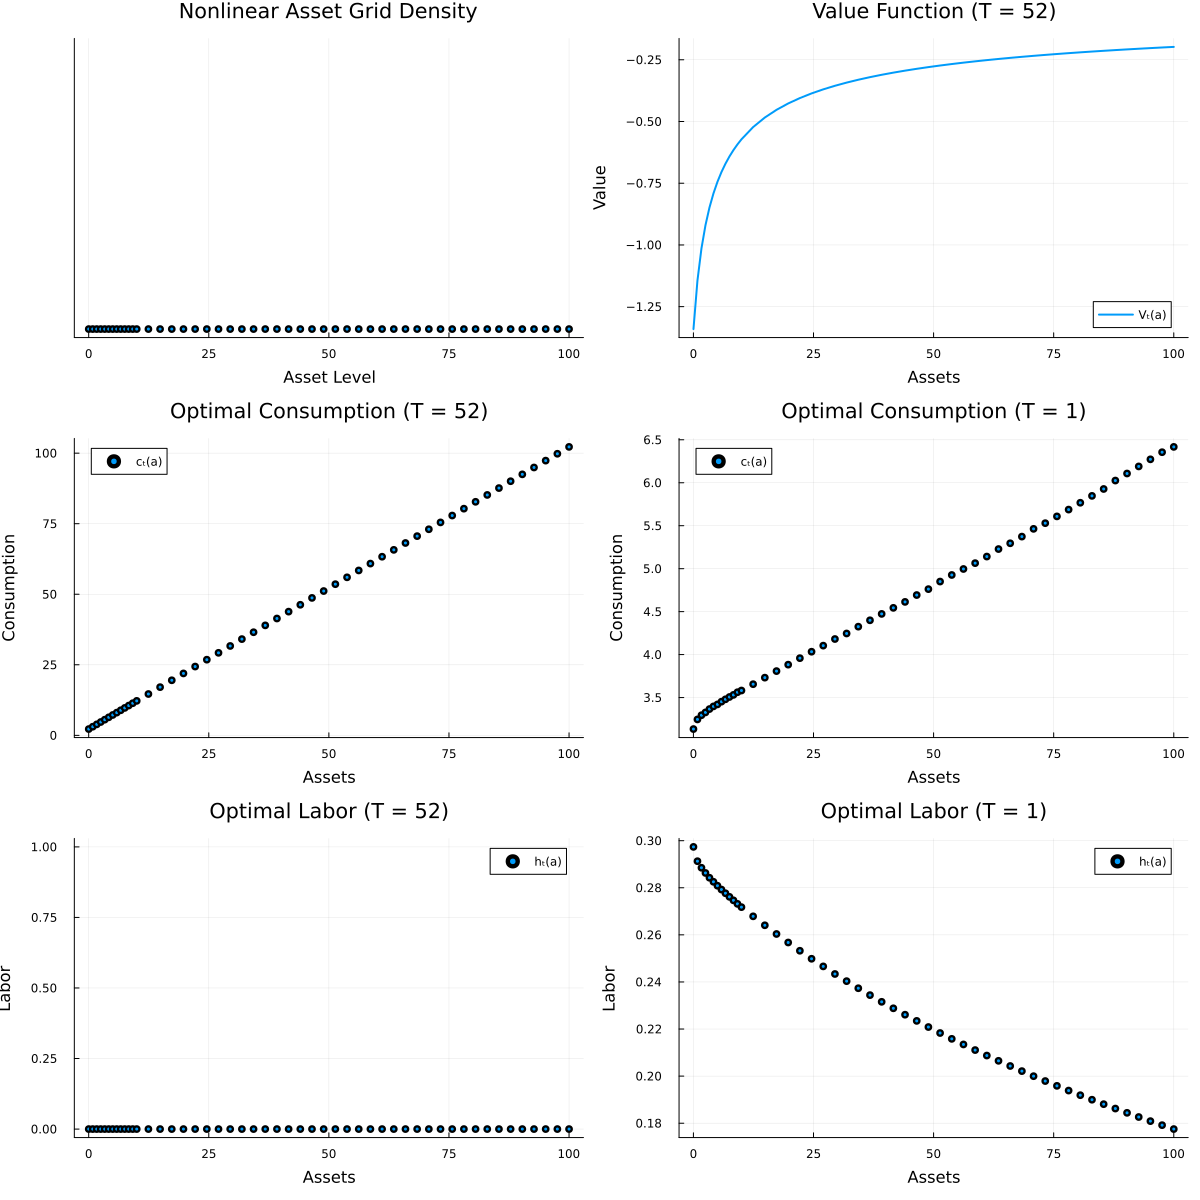

In [75]:

# -----------------------------------------
# Pick “mid‐grid” indices for a, k, t, and p
# -----------------------------------------
k_mid   = ceil(Int, length(model_baseline.k_grid)/2)

p_mid   = ceil(Int, length(model_baseline.p_grid)/2)
t_mid = ceil(Int, length(model_baseline.t_grid)/2)

T_terminal = model_baseline.T   # terminal period
t_early    = 1        # an earlier period

# 1. Plot the nonlinear asset grid
p1 = scatter(model_baseline.a_grid, zeros(length(model_baseline.a_grid)),
    xlabel = "Asset Level",
    yticks = [],
    title = "Nonlinear Asset Grid Density",
    markersize = 3,
    legend = false)

# 2. Plot optimal consumption policy at terminal period (T = model.T)
# Here we fix the labor dimension at k_mid.
p2 = scatter(model_baseline.a_grid, model_baseline.sol_c_work[T_terminal, :, k_mid, p_mid, t_mid],
    xlabel = "Assets",
    ylabel = "Consumption",
    title = "Optimal Consumption (T = $(T_terminal))",
    label = "cₜ(a)",
    markersize = 3)

# 3. Plot value function at terminal period (T = model.T)
# Note: use 'sol_v' (not sol_V) as per your definition.
p3 = plot(model_baseline.a_grid, model_baseline.sol_v_work[T_terminal, :, k_mid, p_mid, t_mid],
    xlabel = "Assets",
    ylabel = "Value",
    title = "Value Function (T = $(T_terminal))",
    label = "Vₜ(a)",
    linewidth = 2)

# 4. Plot optimal consumption policy at an earlier period (e.g., T = 10)
p4 = scatter(model_baseline.a_grid, model_baseline.sol_c_work[t_early, :, k_mid, p_mid, t_mid],
    xlabel = "Assets",
    ylabel = "Consumption",
    title = "Optimal Consumption (T = $(t_early))",
    label = "cₜ(a)",
    markersize = 3)

p5 = scatter(model_baseline.a_grid, model_baseline.sol_h_work[t_early, :, k_mid, p_mid, t_mid],
    xlabel = "Assets",
    ylabel = "Labor",
    title = "Optimal Labor (T = $(t_early))",
    label = "hₜ(a)",
    markersize = 3)

p6 = scatter(model_baseline.a_grid, model_baseline.sol_h_work[T_terminal, :, k_mid, p_mid, t_mid],
    xlabel = "Assets",
    ylabel = "Labor",
    title = "Optimal Labor (T = $(T_terminal))",
    label = "hₜ(a)",
    markersize = 3)

# Combine all plots into a 2×2 grid layout for comparison
plot(p1, p3, p2, p4, p6, p5, layout = (3, 2), size = (1200, 1200))



In [76]:
# -----------------------------
# Extraction function to compute average time series by group
# -----------------------------
function extract_simulation_by_path(model, path_choice)
    T = model.T
    # Find indices of agents by their choice
    college_idx = findall(x -> x == :college, path_choice)
    work_idx    = findall(x -> x == :work, path_choice)
    
    # Compute the average for each time period over the agents in each group
    avg_c_college = [mean(model.sim_c[college_idx, t]) for t in 1:T]
    avg_c_work    = [mean(model.sim_c[work_idx, t]) for t in 1:T]
    
    avg_a_college = [mean(model.sim_a[college_idx, t]) for t in 1:T]
    avg_a_work    = [mean(model.sim_a[work_idx, t]) for t in 1:T]
    
    avg_h_college = [mean(model.sim_h[college_idx, t]) for t in 1:T]
    avg_h_work    = [mean(model.sim_h[work_idx, t]) for t in 1:T]
    
    avg_k_college = [mean(model.sim_k[college_idx, t]) for t in 1:T]
    avg_k_work    = [mean(model.sim_k[work_idx, t]) for t in 1:T]
    
    avg_income_college = [mean(model.sim_income[college_idx, t]) for t in 1:T]
    avg_income_work    = [mean(model.sim_income[work_idx, t]) for t in 1:T]
    
    avg_wage_college = [mean(model.sim_wage[college_idx, t]) for t in 1:T]
    avg_wage_work    = [mean(model.sim_wage[work_idx, t]) for t in 1:T]
    
    return (
      c      = (college = avg_c_college,   work = avg_c_work),
      a      = (college = avg_a_college,   work = avg_a_work),
      h      = (college = avg_h_college,   work = avg_h_work),
      k      = (college = avg_k_college,   work = avg_k_work),
      income = (college = avg_income_college, work = avg_income_work),
      wage   = (college = avg_wage_college,   work = avg_wage_work)
    )
end

baseline_sim = extract_simulation_by_path(model_baseline_child, path_choice_baseline_child);



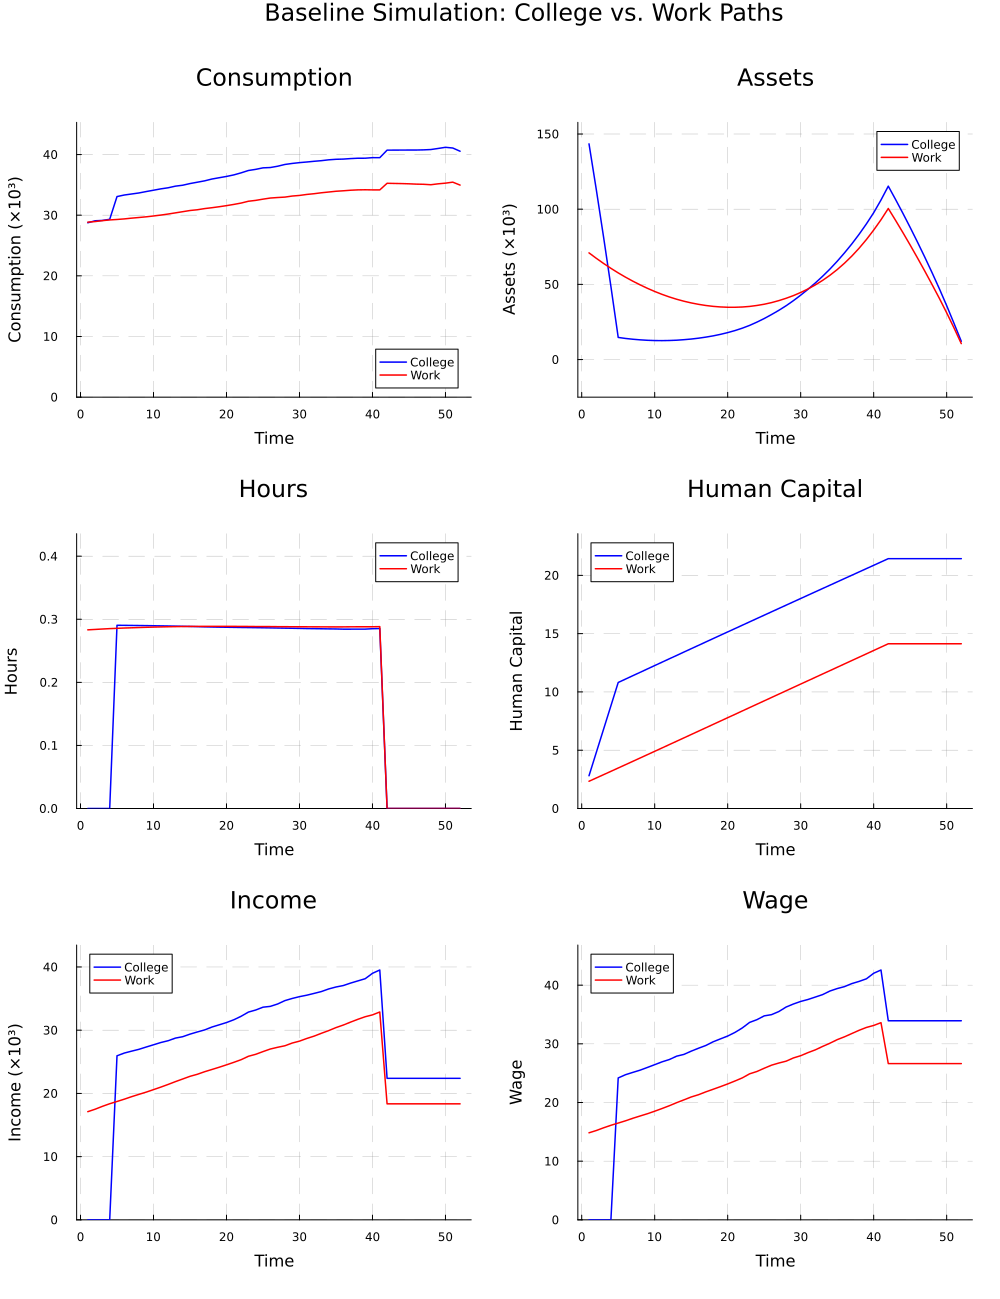

In [77]:
function plot_simulation_results(model, path_choice, common_title="Counterfactual\n(r increased from X% to Y%)"; baseline_sim=nothing)
    # Extract simulation results for the current model
    sim_results = extract_simulation_by_path(model, path_choice)
    t = 1:model.T  # time vector

    # Colors & line widths
    college_color = :blue
    work_color    = :red
    main_lw       = 1.5
    base_lw       = 1.0

    # Helper for subtle dashed grid lines
    function style_grid!(p)
        plot!(p, grid=:on, gridstyle=:dash, gridcolor=:gray, gridalpha=0.5)
    end

    # Formatter to divide y-values by 1000 (e.g., 60000 → "60")
    thousand_formatter = (val -> @sprintf("%.0f", val * 10))

    # Calculate y-axis limits safely
    ymax_c = maximum(vcat(sim_results.c.college, sim_results.c.work)) * 1.1
    ymax_a = maximum(vcat(sim_results.a.college, sim_results.a.work)) * 1.1
    if baseline_sim !== nothing
        ymax_c = maximum(vcat(sim_results.c.college, sim_results.c.work, baseline_sim.c.college, baseline_sim.c.work)) * 1.1
        ymax_a = maximum(vcat(sim_results.a.college, sim_results.a.work, baseline_sim.a.college, baseline_sim.a.work)) * 1.1
    end

    ## ------------------- PLOT 1: Consumption ------------------- ##
    p1 = plot(t, sim_results.c.college,
        label="College", lw=main_lw, color=college_color,
        xlabel="Time", ylabel="Consumption (×10³)", ylims=(0, ymax_c),
        title="Consumption", legend=:bottomright
    )
    plot!(p1, t, sim_results.c.work,
        label="Work", lw=main_lw, color=work_color)

    if baseline_sim !== nothing
        plot!(p1, t, baseline_sim.c.college,
            label="College (Base)", lw=base_lw, color=college_color,
            linestyle=:dash)
        plot!(p1, t, baseline_sim.c.work,
            label="Work (Base)", lw=base_lw, color=work_color,
            linestyle=:dash)
    end
    plot!(p1, yformatter=thousand_formatter)
    style_grid!(p1)

    ## ------------------- PLOT 2: Assets ------------------- ##
    p2 = plot(t, sim_results.a.college,
        label="College", lw=main_lw, color=college_color,
        xlabel="Time", ylabel="Assets (×10³)", ylims=(-2.5, ymax_a),
        title="Assets"
    )
    plot!(p2, t, sim_results.a.work,
        label="Work", lw=main_lw, color=work_color)

    if baseline_sim !== nothing
        plot!(p2, t, baseline_sim.a.college,
            label="College (Base)", lw=base_lw, color=college_color,
            linestyle=:dash)
        plot!(p2, t, baseline_sim.a.work,
            label="Work (Base)", lw=base_lw, color=work_color,
            linestyle=:dash)
    end
    plot!(p2, yformatter=thousand_formatter)
    style_grid!(p2)

    ## ------------------- PLOT 3: Hours ------------------- ##
    ymax_h = maximum(vcat(sim_results.h.college, sim_results.h.work)) * 1.5
    if baseline_sim !== nothing
        ymax_h = maximum(vcat(sim_results.h.college, sim_results.h.work, baseline_sim.h.college, baseline_sim.h.work)) * 1.5
    end
    p3 = plot(t, sim_results.h.college,
        label="College", lw=main_lw, color=college_color,
        xlabel="Time", ylabel="Hours", ylims=(0, ymax_h),
        title="Hours"
    )
    plot!(p3, t, sim_results.h.work,
        label="Work", lw=main_lw, color=work_color)

    if baseline_sim !== nothing
        plot!(p3, t, baseline_sim.h.college,
            label="College (Base)", lw=base_lw, color=college_color,
            linestyle=:dash)
        plot!(p3, t, baseline_sim.h.work,
            label="Work (Base)", lw=base_lw, color=work_color,
            linestyle=:dash)
    end
    style_grid!(p3)

    ## ------------------- PLOT 4: Human Capital ------------------- ##
    ymax_k = maximum(vcat(sim_results.k.college, sim_results.k.work)) * 1.1
    if baseline_sim !== nothing
        ymax_k = maximum(vcat(sim_results.k.college, sim_results.k.work, baseline_sim.k.college, baseline_sim.k.work)) * 1.1
    end
    p4 = plot(t, sim_results.k.college,
        label="College", lw=main_lw, color=college_color,
        xlabel="Time", ylabel="Human Capital", ylims=(0, ymax_k),
        title="Human Capital"
    )
    plot!(p4, t, sim_results.k.work,
        label="Work", lw=main_lw, color=work_color)

    if baseline_sim !== nothing
        plot!(p4, t, baseline_sim.k.college,
            label="College (Base)", lw=base_lw, color=college_color,
            linestyle=:dash)
        plot!(p4, t, baseline_sim.k.work,
            label="Work (Base)", lw=base_lw, color=work_color,
            linestyle=:dash)
    end
    style_grid!(p4)

    ## ------------------- PLOT 5: Income ------------------- ##
    ymax_income = maximum(vcat(sim_results.income.college, sim_results.income.work)) * 1.1
    if baseline_sim !== nothing
        ymax_income = maximum(vcat(sim_results.income.college, sim_results.income.work, baseline_sim.income.college, baseline_sim.income.work)) * 1.1
    end
    p5 = plot(t, sim_results.income.college,
        label="College", lw=main_lw, color=college_color,
        xlabel="Time", ylabel="Income (×10³)", ylims=(0, ymax_income),
        title="Income"
    )
    plot!(p5, t, sim_results.income.work,
        label="Work", lw=main_lw, color=work_color)

    if baseline_sim !== nothing
        plot!(p5, t, baseline_sim.income.college,
            label="College (Base)", lw=base_lw, color=college_color,
            linestyle=:dash)
        plot!(p5, t, baseline_sim.income.work,
            label="Work (Base)", lw=base_lw, color=work_color,
            linestyle=:dash)
    end
    plot!(p5, yformatter=thousand_formatter)
    style_grid!(p5)

    ## ------------------- PLOT 6: Wage ------------------- ##
    ymax_wage = maximum(vcat(sim_results.wage.college, sim_results.wage.work)) * 1.1
    if baseline_sim !== nothing
        ymax_wage = maximum(vcat(sim_results.wage.college, sim_results.wage.work, baseline_sim.wage.college, baseline_sim.wage.work)) * 1.1
    end
    p6 = plot(t, sim_results.wage.college,
        label="College", lw=main_lw, color=college_color,
        xlabel="Time", ylabel="Wage", ylims=(0, ymax_wage),
        title="Wage"
    )
    plot!(p6, t, sim_results.wage.work,
        label="Work", lw=main_lw, color=work_color)

    if baseline_sim !== nothing
        plot!(p6, t, baseline_sim.wage.college,
            label="College (Base)", lw=base_lw, color=college_color,
            linestyle=:dash)
        plot!(p6, t, baseline_sim.wage.work,
            label="Work (Base)", lw=base_lw, color=work_color,
            linestyle=:dash)
    end
    plot!(p6)
    style_grid!(p6)

    # Combine the six subplots into a 2x3 layout
    combined_plot = plot(
        p1, p2, p3, p4, p5, p6,
        layout=(3, 2),
        size=(1000, 1300),
        plot_title=common_title,
        titlefont=16,
        margin=5mm
    )

    return combined_plot
end

# Example usage
p_baseline = plot_simulation_results(model_baseline_child, path_choice_baseline_child,
                                     "Baseline Simulation: College vs. Work Paths")

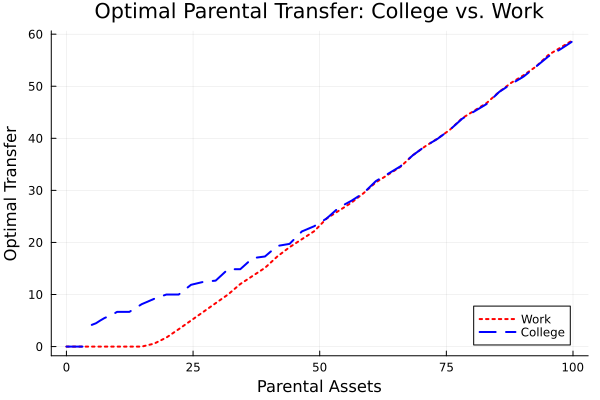

In [78]:
# Pick a mid human capital, AR1, and transitory shock index (as in your code)
k_mid = ceil(Int, length(model_baseline_family.k_grid)/2)
p_mid = ceil(Int, length(model_baseline_family.p_grid)/2)
t_mid = ceil(Int, length(model_baseline_family.t_grid)/2)

a_vals = model_baseline_family.a_grid

# Extract optimal transfers for work (doesn't depend on t)
tr_work = model_baseline_family.sol_tr_work[:, k_mid, p_mid, 1]

# Extract optimal transfers for college at chosen t node
tr_college = model_baseline_family.sol_tr_college[:, k_mid, p_mid, t_mid]

# Clean up (set to NaN if negative, for plotting)
tr_work_plot = copy(tr_work)
#tr_work_plot[tr_work .<= 0.0] .= NaN
tr_college_plot = copy(tr_college)
#tr_college_plot[tr_college .<= 0.0] .= NaN

# Plot
plot(
    a_vals, tr_work_plot, 
    label = "Work", 
    linewidth = 2, 
    linestyle = :dot, 
    color = :red,
    xlabel = "Parental Assets", 
    ylabel = "Optimal Transfer", 
    title = "Optimal Parental Transfer: College vs. Work"
)
plot!(
    a_vals, tr_college_plot, 
    label = "College", 
    linewidth = 2, 
    linestyle = :dash, 
    color = :blue
)

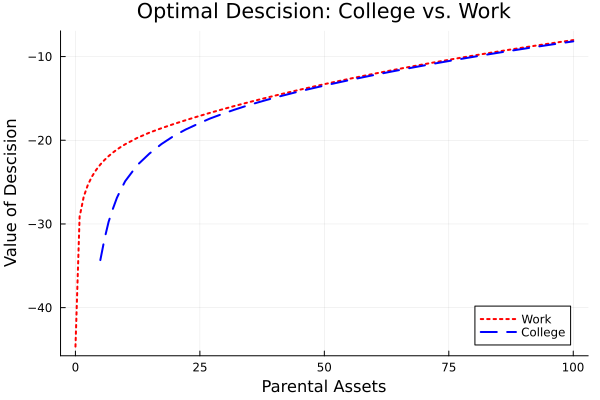

In [79]:
using Plots

# Pick a mid human capital, AR1, and transitory shock index
k_mid = ceil(Int, length(model_baseline_family.k_grid) / 2)
p_mid = ceil(Int, length(model_baseline_family.p_grid) / 2)
t_mid = ceil(Int, length(model_baseline_family.t_grid) / 2)

a_vals = model_baseline_family.a_grid

# Extract optimal transfers for work (doesn't depend on t)
tr_work = model_baseline_family.sol_tr_v_work[:, k_mid, p_mid, 1]

# Extract optimal transfers for college at chosen t node
tr_college = model_baseline_family.sol_tr_v_college[:, k_mid, p_mid, t_mid]

# Plot
plot(
    a_vals, tr_work,
    label = "Work",
    linewidth = 2,
    linestyle = :dot,
    color = :red,
    xlabel = "Parental Assets",
    ylabel = "Value of Descision",
    title = "Optimal Descision: College vs. Work"
)
plot!(
    a_vals, tr_college,
    label = "College",
    linewidth = 2,
    linestyle = :dash,
    color = :blue
)

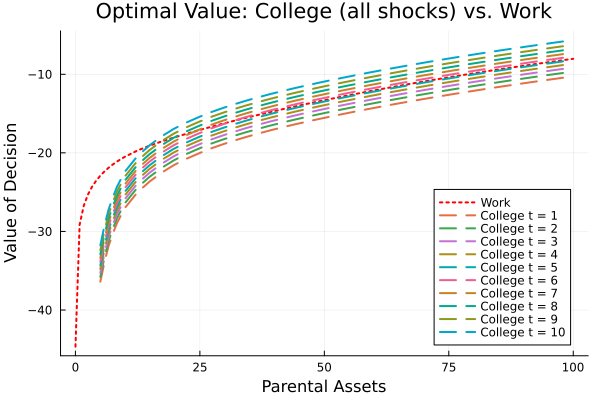

In [80]:

# Pick a mid human capital and AR1 index
k_mid = ceil(Int, length(model_baseline_family.k_grid) / 2)
p_mid = ceil(Int, length(model_baseline_family.p_grid) / 2)
Nt = length(model_baseline_family.t_grid)

a_vals = model_baseline_family.a_grid

# Extract optimal values for work (doesn't depend on t)
tr_work = model_baseline_family.sol_tr_v_work[:, k_mid, p_mid, 1]

# Plot work once
plt = plot(
    a_vals, tr_work,
    label = "Work",
    linewidth = 2,
    linestyle = :dot,
    color = :red,
    xlabel = "Parental Assets",
    ylabel = "Value of Decision",
    title = "Optimal Value: College (all shocks) vs. Work"
)

# Overlay all college value curves for different i_t
for t in 1:Nt
    tr_college = model_baseline_family.sol_tr_v_college[:, k_mid, p_mid, t]
    plot!(
        a_vals, tr_college,
        label = "College t = $t",
        linewidth = 2,
        linestyle = :dash,
        color = :auto # Plots will pick a different color for each
    )
end

display(plt)

In [81]:
k_mid = ceil(Int, length(model_baseline_family.k_grid)/2)
p_mid = ceil(Int, length(model_baseline_family.p_grid)/2)
t_mid = ceil(Int, length(model_baseline_family.t_grid)/2)

a_vals = model_baseline_family.a_grid

tr_work    = model_baseline_family.sol_tr_work[:, k_mid, p_mid, 1]
tr_college = model_baseline_family.sol_tr_college[:, k_mid, p_mid, t_mid]

# Combine into a table (DataFrame for pretty display)
using DataFrames

df = DataFrame(
    Asset_Grid = a_vals,
    Transfer_Work = tr_work,
    Transfer_College = tr_college
)

print(df)

50×3 DataFrame
 Row │ Asset_Grid  Transfer_Work  Transfer_College 
     │ Float64     Float64        Float64          
─────┼─────────────────────────────────────────────
   1 │     0.01         1.0e-6             0.0
   2 │     0.8425       1.0e-6             0.0
   3 │     1.675        1.0e-6             0.0
   4 │     2.5075       1.0e-6             0.0
   5 │     3.34         1.0e-6             0.0
   6 │     4.1725       1.0e-6           NaN
   7 │     5.005        1.0e-6             4.1725
   8 │     5.8375       1.0e-6             4.48544
   9 │     6.67         1.0e-6             5.00497
  10 │     7.5025       1.0e-6             5.48013
  11 │     8.335        1.0e-6             5.83758
  12 │     9.1675       1.0e-6             6.20024
  13 │    10.0          1.0e-6             6.6699
  14 │    12.4324       1.0e-6             6.67409
  15 │    14.8649       1.0e-6             8.14915
  16 │    17.2973       0.564683           9.16755
  17 │    19.7297       1.73217          